# Notebook 01 — Hayhurst Solar: CMIP6 Data & SCVR

**Site:** Hayhurst Texas Solar — Culberson County, TX (24.8 MW, arid/desert)  
**Scenario:** SSP2-4.5 (≈ RCP 4.5, moderate emissions pathway)  
**Model:** EC_Earth3P_HR — confirmed working on Open-Meteo Climate API (all 7 core variables incl. rsds and hurs)

## What this notebook does

1. **Fetches real CMIP6 climate data** for this site from the Open-Meteo Climate API  
   (EC_Earth3P_HR historical run 1950–2014 as baseline + SSP2-4.5 future 2015–2050)
2. **Stores data as Parquet** using the schema defined in `data/schema/`
3. **Characterises the baseline climate** so we can visually verify the data is physically realistic
4. **Computes extreme climate indices** (heat waves, frost days, dry spells, etc.)
5. **Computes SCVR** — the central metric that feeds HCR and EFR in later notebooks
6. **Visualises** exceedance curve shifts, SCVR evolution, and a sanity-check temperature trend

## Pre-requisites

Run from project root with the venv activated:
```bash
source .venv/bin/activate
python scripts/tests/test_openmeteo_api.py  # confirm API is reachable
python scripts/tests/test_parquet_io.py     # confirm Parquet works
python scripts/tests/test_scvr_math.py      # confirm SCVR math is correct
jupyter lab
```

---
## Section 0 — Setup & Configuration

In [12]:
import json
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import requests
import seaborn as sns

warnings.filterwarnings('ignore')

# ── Repo root (works regardless of where Jupyter was launched from) ──────────
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'requirements.txt').exists():
    REPO_ROOT = REPO_ROOT.parent
    if REPO_ROOT == REPO_ROOT.parent:
        raise FileNotFoundError('requirements.txt not found — run notebook from project root')

SCHEMA_DIR   = REPO_ROOT / 'data' / 'schema'
RAW_DIR      = REPO_ROOT / 'data' / 'raw' / 'cmip6'
PROCESSED_DIR= REPO_ROOT / 'data' / 'processed' / 'scvr'

print(f'Repo root : {REPO_ROOT}')
print(f'Schema dir: {SCHEMA_DIR}')

Repo root : /Users/divy/code/work/infrasure_git_codes/LTRisk
Schema dir: /Users/divy/code/work/infrasure_git_codes/LTRisk/data/schema


In [13]:
# ── Load schema files ─────────────────────────────────────────────────────────
with open(SCHEMA_DIR / 'sites.json') as f:
    SITES = json.load(f)

with open(SCHEMA_DIR / 'variables.json') as f:
    VARIABLES = json.load(f)

# ── Select site ───────────────────────────────────────────────────────────────
SITE_ID = 'hayhurst_solar'
SITE    = SITES[SITE_ID]
LAT     = SITE['lat']
LON     = SITE['lon']
MODEL   = SITE['open_meteo_model']   # 'EC_Earth3P_HR' (from sites.json — confirmed working)
SCENARIO_CODE = 'ssp245'  # ⚠️  LABEL ONLY — does not change the API data.
# The Open-Meteo HighResMIP models all run under approximately SSP5-8.5 (high-emissions).
# This label is used for file naming and metadata only.
# Proof: Plot D shows +3.3°C warming over 70 years — that matches SSP5-8.5, not SSP2-4.5.
# For multi-scenario analysis, use NASA NEX-GDDP-CMIP6 (see docs/data_sources/OPENMETEO_CMIP6_GUIDE.md).

# ── Time ranges ───────────────────────────────────────────────────────────────
BASELINE_START = '1980-01-01'   # subset of EC_Earth3P_HR historical run (covers 1950–2014)
BASELINE_END   = '2014-12-31'
FUTURE_START   = '2015-01-01'
FUTURE_END     = '2049-12-31'  # ⚠️  2050 is entirely null in the Open-Meteo API.

# ── Output paths ──────────────────────────────────────────────────────────────
SITE_RAW_DIR  = RAW_DIR / SITE_ID
SITE_PROC_DIR = PROCESSED_DIR / SITE_ID
FIGURES_DIR   = SITE_PROC_DIR / 'figures'

for d in [SITE_RAW_DIR, SITE_PROC_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({'figure.dpi': 150, 'font.size': 10})
sns.set_style('darkgrid')
PALETTE = {'baseline': '#4472C4', 'ssp245': '#C55A11'}

print(f"Site     : {SITE['name']}")
print(f"Location : lat={LAT}, lon={LON}")
print(f"Scenario : {SCENARIO_CODE}, model: {MODEL}")
print(f"Baseline : {BASELINE_START} → {BASELINE_END}")
print(f"Future   : {FUTURE_START} → {FUTURE_END}")

Site     : Hayhurst Texas Solar
Location : lat=31.815992, lon=-104.0853
Scenario : ssp245, model: EC_Earth3P_HR
Baseline : 1980-01-01 → 2014-12-31
Future   : 2015-01-01 → 2049-12-31


---
## Section 1 — Data Acquisition

We use the **Open-Meteo Climate API** (`climate-api.open-meteo.com`), which serves
pre-extracted NEX-GDDP-CMIP6 daily time series for any lat/lon — no API key needed.

Two pulls:
- **Historical baseline (ERA5):** 1980–2014 — sets our exceedance thresholds
- **Future projection (SSP2-4.5):** 2015–2050 — what we compare against baseline

Data is saved as Parquet once and reloaded on subsequent runs (skip-if-exists logic).

In [14]:
# ── Open-Meteo variable mapping ───────────────────────────────────────────────
# Maps our schema variable names → Open-Meteo API parameter names
OM_PARAMS = {
    'tasmax'  : 'temperature_2m_max',
    'tasmin'  : 'temperature_2m_min',
    'tas'     : 'temperature_2m_mean',
    'pr'      : 'precipitation_sum',
    'sfcWind' : 'wind_speed_10m_mean',
    'hurs'    : 'relative_humidity_2m_mean',
    'rsds'    : 'shortwave_radiation_sum',
}

OM_URL = 'https://climate-api.open-meteo.com/v1/climate'


def fetch_open_meteo(lat: float, lon: float, start: str, end: str,
                     model: str, scenario: str = 'historical') -> pd.DataFrame:
    """
    Fetch daily climate data from Open-Meteo Climate API.

    The Open-Meteo Climate API serves both historical (pre-2015) and future
    (post-2015) data from the same endpoint. The model handles the period
    automatically based on the date range — no separate ERA5 call needed.

    Confirmed working model: EC_Earth3P_HR (all P1+P2 variables).
    See data/schema/VARIABLES.md for full model compatibility table.

    Args:
        lat, lon  : Site coordinates.
        start, end: Date strings YYYY-MM-DD.
        model     : Open-Meteo model code (must be a confirmed model from sites.json).
        scenario  : Label stored in the output column ('historical' or 'ssp245', 'ssp585').
                    Does NOT change the API request — it is metadata only.

    Returns:
        Wide-format DataFrame matching cmip6_raw_schema.json.
    """
    params = {
        'latitude'  : lat,
        'longitude' : lon,
        'start_date': start,
        'end_date'  : end,
        'models'    : model,
        'daily'     : list(OM_PARAMS.values()),
    }

    for attempt in range(3):
        try:
            resp = requests.get(OM_URL, params=params, timeout=60)
            resp.raise_for_status()
            break
        except requests.exceptions.RequestException as e:
            if attempt == 2:
                raise RuntimeError(
                    f"Open-Meteo API failed after 3 attempts.\n"
                    f"URL: {OM_URL}\nParams: {params}\nError: {e}\n\n"
                    f"Check model name in data/schema/sites.json — "
                    f"MRI_ESM2_0 is NOT valid. Use EC_Earth3P_HR."
                )
            print(f'  Retry {attempt+1}/3 after error: {e}')
            time.sleep(5)

    body = resp.json()
    if 'daily' not in body:
        raise ValueError(f"No 'daily' key in response: {body}")
    data = body['daily']
    dates = pd.to_datetime(data['time'])

    df = pd.DataFrame({'date': dates})
    df['year']  = dates.year.astype('int16')
    df['month'] = dates.month.astype('int8')
    df['doy']   = dates.day_of_year.astype('int16')

    for our_name, om_name in OM_PARAMS.items():
        vals = data.get(om_name)
        df[our_name] = pd.array(vals, dtype='float32') if vals is not None else float('nan')

    df['site_id']  = SITE_ID
    df['scenario'] = scenario
    df['model']    = model

    return df


print(f'Fetch function defined. Using model: {MODEL}')

Fetch function defined. Using model: EC_Earth3P_HR


In [15]:
# ── Pull historical baseline ───────────────────────────────────────────────────
baseline_path = SITE_RAW_DIR / f'historical_{MODEL}_1980_2014.parquet'

if baseline_path.exists():
    print('Loading cached baseline data...')
    df_base = pd.read_parquet(baseline_path)
else:
    print(f'Fetching historical baseline from Open-Meteo ({MODEL}, 1980–2014)...')
    df_base = fetch_open_meteo(LAT, LON, BASELINE_START, BASELINE_END,
                               model=MODEL, scenario='historical')
    df_base.to_parquet(baseline_path, index=False, engine='pyarrow')
    print(f'  Saved → {baseline_path.name}')

print(f'Baseline shape : {df_base.shape}')
print(f'Date range     : {df_base["date"].min().date()} → {df_base["date"].max().date()}')
print(f'Null counts    :')
print(df_base[list(OM_PARAMS.keys())].isnull().sum().to_string())

Loading cached baseline data...
Baseline shape : (12784, 14)
Date range     : 1980-01-01 → 2014-12-31
Null counts    :
tasmax     0
tasmin     0
tas        0
pr         0
sfcWind    0
hurs       0
rsds       0


In [16]:
# ── Pull future projection ─────────────────────────────────────────────────────
future_path = SITE_RAW_DIR / f'{SCENARIO_CODE}_{MODEL}_2015_2049.parquet'

if future_path.exists():
    print('Loading cached future projection...')
    df_future = pd.read_parquet(future_path)
else:
    print(f'Fetching future projection from Open-Meteo ({MODEL}, {SCENARIO_CODE}, 2015–2050)...')
    df_future = fetch_open_meteo(LAT, LON, FUTURE_START, FUTURE_END,
                                 model=MODEL, scenario=SCENARIO_CODE)
    df_future.to_parquet(future_path, index=False, engine='pyarrow')
    print(f'  Saved → {future_path.name}')

print(f'Future shape   : {df_future.shape}')
print(f'Date range     : {df_future["date"].min().date()} → {df_future["date"].max().date()}')
print(f'Null counts    :')
print(df_future[list(OM_PARAMS.keys())].isnull().sum().to_string())

Fetching future projection from Open-Meteo (EC_Earth3P_HR, ssp245, 2015–2050)...
  Saved → ssp245_EC_Earth3P_HR_2015_2049.parquet
Future shape   : (12784, 14)
Date range     : 2015-01-01 → 2049-12-31
Null counts    :
tasmax     0
tasmin     0
tas        0
pr         0
sfcWind    0
hurs       0
rsds       0


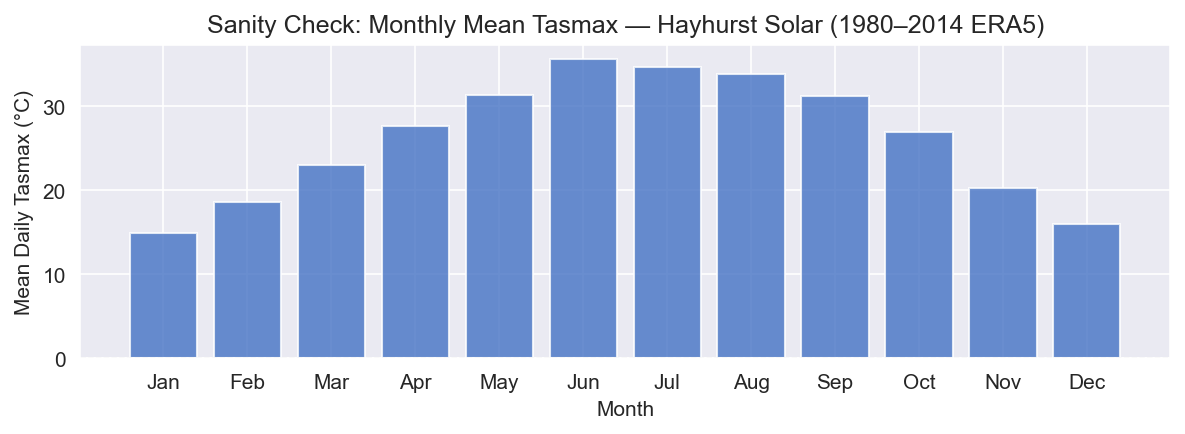

Expected: ~15°C in Jan, ~40°C in Jul for West Texas desert.


In [17]:
# ── Quick sanity check plot ────────────────────────────────────────────────────
# Monthly mean tasmax: Culberson TX should show ~15°C Jan, ~40°C Jul
monthly_base = df_base.groupby('month')['tasmax'].mean()

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(monthly_base.index, monthly_base.values, color=PALETTE['baseline'], alpha=0.8)
ax.set_xlabel('Month')
ax.set_ylabel('Mean Daily Tasmax (°C)')
ax.set_title('Sanity Check: Monthly Mean Tasmax — Hayhurst Solar (1980–2014 ERA5)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.axhline(0, color='grey', lw=0.7, ls='--')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'sanity_monthly_tasmax.png', dpi=150)
plt.show()
print('Expected: ~15°C in Jan, ~40°C in Jul for West Texas desert.')

---
## Section 2 — Baseline Characterisation

Before computing anything, we need to confirm the data is physically realistic
for Culberson County, West Texas (arid/desert climate zone).

Expected characteristics:
- **Temperature:** Hot dry summers (~40°C tasmax in July), mild winters (~15°C)
- **Precipitation:** Very low (~250 mm/year), skewed toward summer thunderstorms
- **Wind:** Moderate, slight seasonal pattern
- **Solar (rsds):** Very high — one of the highest irradiance regions in the US

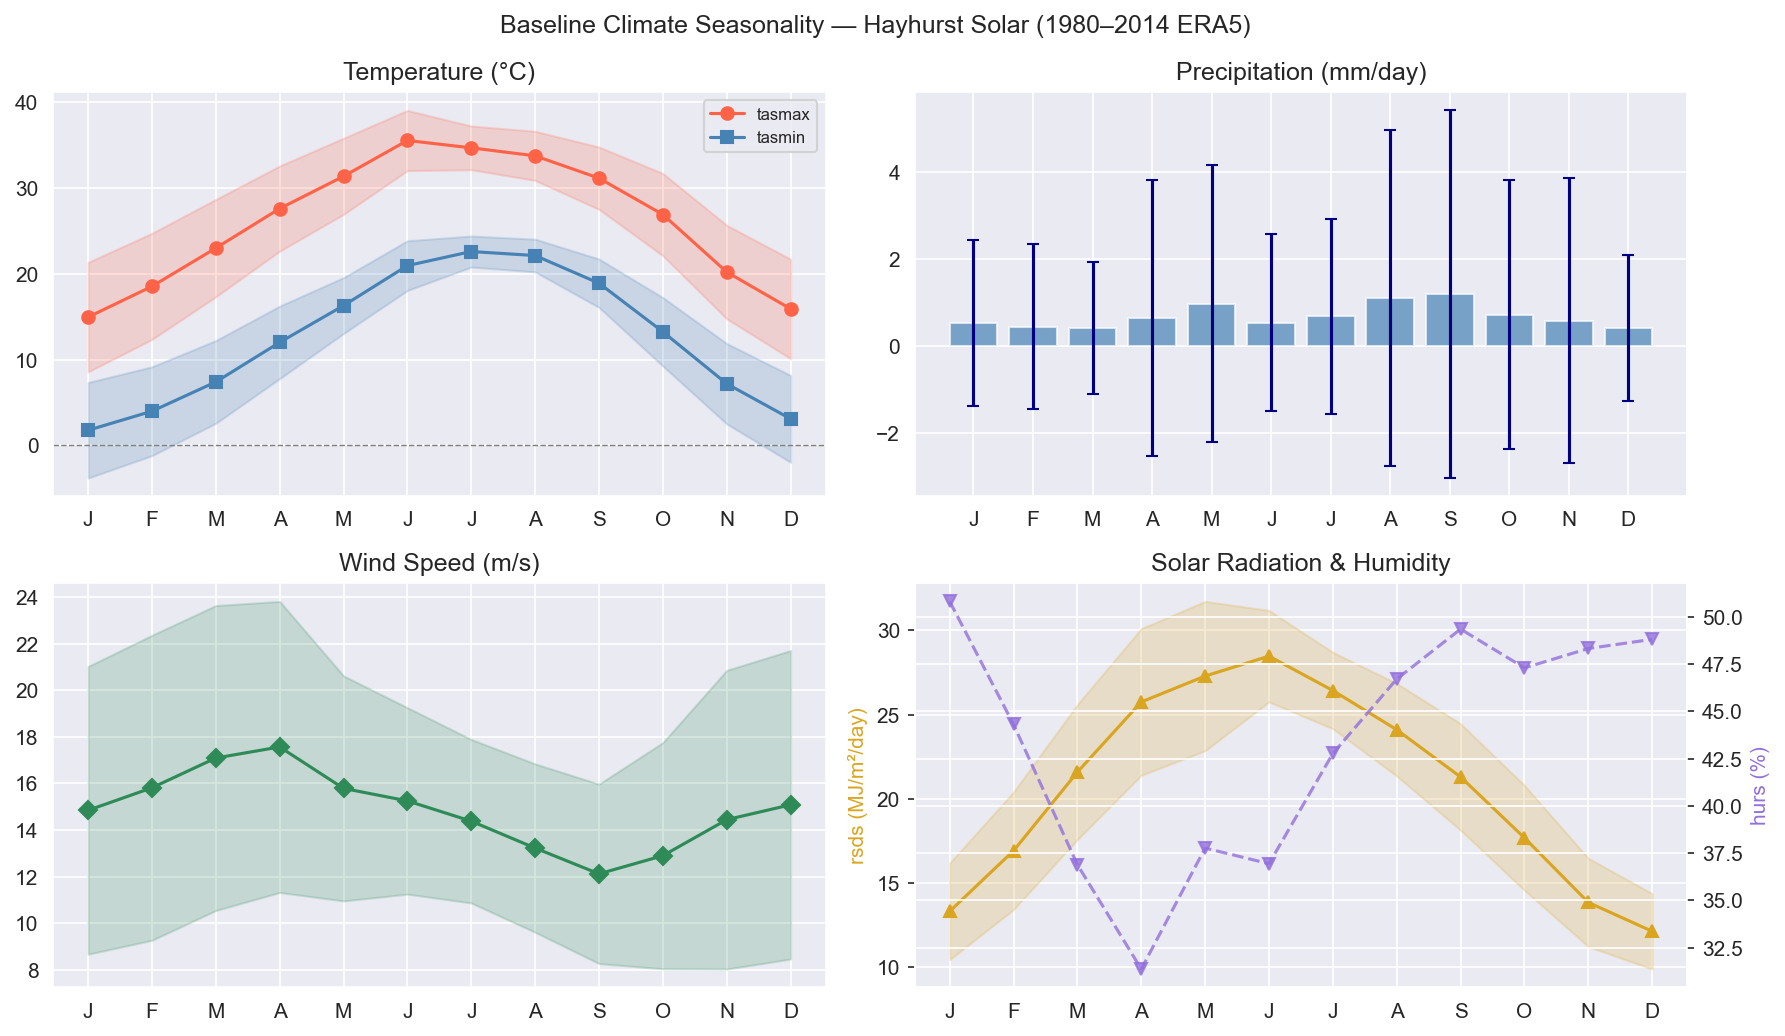

In [18]:
# ── Seasonal climatology plot ──────────────────────────────────────────────────
monthly = df_base.groupby('month').agg(
    tasmax_mean=('tasmax', 'mean'), tasmax_std=('tasmax', 'std'),
    tasmin_mean=('tasmin', 'mean'), tasmin_std=('tasmin', 'std'),
    pr_mean=('pr', 'mean'), pr_std=('pr', 'std'),
    sfcWind_mean=('sfcWind', 'mean'), sfcWind_std=('sfcWind', 'std'),
    rsds_mean=('rsds', 'mean'), rsds_std=('rsds', 'std'),
    hurs_mean=('hurs', 'mean'), hurs_std=('hurs', 'std'),
)
months = monthly.index
month_labels = ['J','F','M','A','M','J','J','A','S','O','N','D']

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
fig.suptitle('Baseline Climate Seasonality — Hayhurst Solar (1980–2014 ERA5)', fontsize=12)

# Temperature
ax = axes[0, 0]
ax.fill_between(months,
                monthly['tasmax_mean'] - monthly['tasmax_std'],
                monthly['tasmax_mean'] + monthly['tasmax_std'],
                alpha=0.2, color='tomato')
ax.plot(months, monthly['tasmax_mean'], 'o-', color='tomato', label='tasmax')
ax.fill_between(months,
                monthly['tasmin_mean'] - monthly['tasmin_std'],
                monthly['tasmin_mean'] + monthly['tasmin_std'],
                alpha=0.2, color='steelblue')
ax.plot(months, monthly['tasmin_mean'], 's-', color='steelblue', label='tasmin')
ax.axhline(0, color='grey', lw=0.7, ls='--')
ax.set_title('Temperature (°C)')
ax.set_xticks(months); ax.set_xticklabels(month_labels)
ax.legend(fontsize=8)

# Precipitation
ax = axes[0, 1]
ax.bar(months, monthly['pr_mean'], color='steelblue', alpha=0.7, label='mean')
ax.errorbar(months, monthly['pr_mean'], monthly['pr_std'],
            fmt='none', color='navy', capsize=3)
ax.set_title('Precipitation (mm/day)')
ax.set_xticks(months); ax.set_xticklabels(month_labels)

# Wind
ax = axes[1, 0]
ax.fill_between(months,
                monthly['sfcWind_mean'] - monthly['sfcWind_std'],
                monthly['sfcWind_mean'] + monthly['sfcWind_std'],
                alpha=0.2, color='seagreen')
ax.plot(months, monthly['sfcWind_mean'], 'D-', color='seagreen')
ax.set_title('Wind Speed (m/s)')
ax.set_xticks(months); ax.set_xticklabels(month_labels)

# Solar + Humidity
ax = axes[1, 1]
ax2 = ax.twinx()
ax.fill_between(months,
                monthly['rsds_mean'] - monthly['rsds_std'],
                monthly['rsds_mean'] + monthly['rsds_std'],
                alpha=0.2, color='goldenrod')
ax.plot(months, monthly['rsds_mean'], '^-', color='goldenrod', label='rsds (MJ/m²)')
ax2.plot(months, monthly['hurs_mean'], 'v--', color='mediumpurple', label='hurs (%)', alpha=0.8)
ax.set_title('Solar Radiation & Humidity')
ax.set_xticks(months); ax.set_xticklabels(month_labels)
ax.set_ylabel('rsds (MJ/m²/day)', color='goldenrod')
ax2.set_ylabel('hurs (%)', color='mediumpurple')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'baseline_seasonality.png', dpi=150)
plt.show()

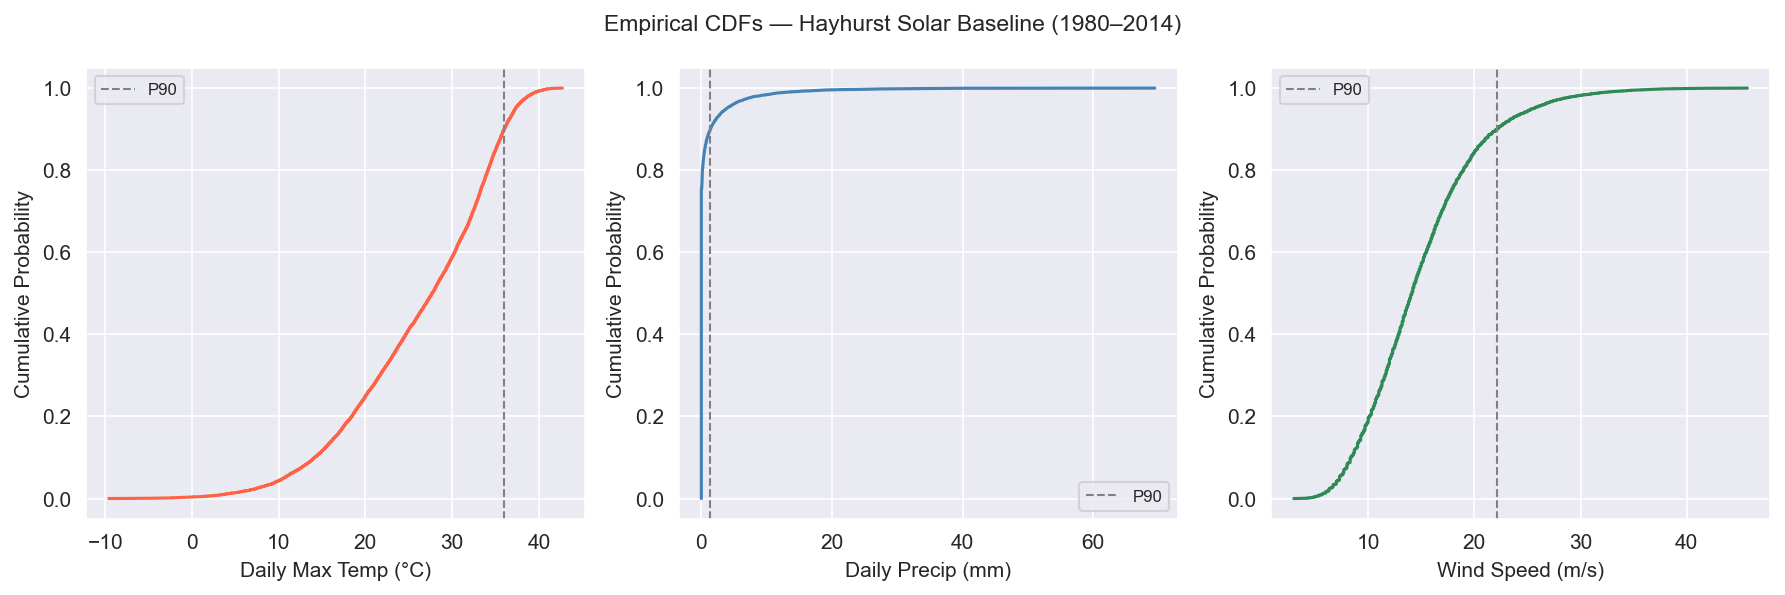

In [19]:
# ── Empirical CDFs for key variables ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle('Empirical CDFs — Hayhurst Solar Baseline (1980–2014)', fontsize=11)

for ax, col, label, color in zip(
    axes,
    ['tasmax', 'pr', 'sfcWind'],
    ['Daily Max Temp (°C)', 'Daily Precip (mm)', 'Wind Speed (m/s)'],
    ['tomato', 'steelblue', 'seagreen'],
):
    vals = df_base[col].dropna().sort_values().values
    cdf  = np.arange(1, len(vals) + 1) / len(vals)
    ax.plot(vals, cdf, color=color, lw=1.5)
    ax.axvline(np.percentile(vals, 90), color='grey', ls='--', lw=1, label='P90')
    ax.set_xlabel(label)
    ax.set_ylabel('Cumulative Probability')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'baseline_cdfs.png', dpi=150)
plt.show()

---
## Section 3 — Extreme Climate Indices

Before computing SCVR we compute **annual extreme indices** — counts or statistics
that summarise how often threshold-exceeding events occur in each year.
These are the building blocks that SCVR will aggregate.

All thresholds (P90, P10, etc.) are derived from the **baseline period only** and
applied consistently to both baseline and future data.

In [20]:
# ── Baseline thresholds ────────────────────────────────────────────────────────
P90_TASMAX = float(np.percentile(df_base['tasmax'].dropna(), 90))
P90_TASMIN = float(np.percentile(df_base['tasmin'].dropna(), 90))
P10_TASMAX = float(np.percentile(df_base['tasmax'].dropna(), 10))
P10_TASMIN = float(np.percentile(df_base['tasmin'].dropna(), 10))

print(f'Baseline thresholds (Culberson TX):')
print(f'  P90 tasmax : {P90_TASMAX:.1f} °C')
print(f'  P90 tasmin : {P90_TASMIN:.1f} °C')
print(f'  P10 tasmax : {P10_TASMAX:.1f} °C  (cold wave upper bound)')
print(f'  P10 tasmin : {P10_TASMIN:.1f} °C  (cold wave lower bound)')

Baseline thresholds (Culberson TX):
  P90 tasmax : 36.0 °C
  P90 tasmin : 22.8 °C
  P10 tasmax : 14.1 °C  (cold wave upper bound)
  P10 tasmin : 0.8 °C  (cold wave lower bound)


In [21]:
# ── Index computation functions ────────────────────────────────────────────────

def count_consecutive_events(condition: pd.Series, min_run: int = 3) -> int:
    """Count days that fall within runs of `min_run` or more consecutive True days."""
    runs = condition.astype(int)
    # Label each run with a group ID
    groups = (runs != runs.shift()).cumsum()
    counts = runs.groupby(groups).transform('sum')
    return int((condition & (counts >= min_run)).sum())


def compute_annual_indices(df: pd.DataFrame) -> pd.DataFrame:
    """Compute annual extreme climate indices for a daily DataFrame."""
    rows = []
    for year, grp in df.groupby('year'):
        grp = grp.sort_values('date').reset_index(drop=True)

        # 1. Heat wave days (3+ consecutive days both tasmax>P90 AND tasmin>P90)
        hw_cond = (grp['tasmax'] > P90_TASMAX) & (grp['tasmin'] > P90_TASMIN)
        hw_days = count_consecutive_events(hw_cond, min_run=3)

        # 2. Frost days (tasmin < 0°C)
        frost_days = int((grp['tasmin'] < 0).sum())

        # 3. Icing days (tasmax < 0°C — entire day below freezing)
        icing_days = int((grp['tasmax'] < 0).sum())

        # 4. Rx5day — annual maximum of 5-day rolling precipitation sum
        rx5day = float(grp['pr'].rolling(5, min_periods=5).sum().max())

        # 5. Max consecutive dry days (pr = 0)
        dry_runs   = (grp['pr'] == 0).astype(int)
        run_groups = (dry_runs != dry_runs.shift()).cumsum()
        dry_counts = dry_runs.groupby(run_groups).transform('sum') * dry_runs
        max_dry    = int(dry_counts.max()) if len(dry_counts) > 0 else 0

        # 6. Wind cut-out days (sfcWind > 25 m/s)
        cutout_days = int((grp['sfcWind'] > 25).sum())

        # 7. Fire Weather Index (simplified composite proxy)
        # Normalise each component to [0,1] and combine with weights
        def safe_norm(s, invert=False):
            rng = s.max() - s.min()
            norm = (s - s.min()) / rng if rng > 0 else pd.Series(0.5, index=s.index)
            return 1 - norm if invert else norm

        fwi = (
            0.30 * safe_norm(grp['tasmax']) +
            0.30 * safe_norm(grp['hurs'], invert=True) +
            0.20 * safe_norm(grp['sfcWind']) +
            0.20 * safe_norm(grp['pr'], invert=True)
        )
        fwi_mean = float(fwi.mean())

        rows.append({
            'year'           : year,
            'heat_wave_days' : hw_days,
            'frost_days'     : frost_days,
            'icing_days'     : icing_days,
            'rx5day_mm'      : rx5day,
            'max_dry_days'   : max_dry,
            'wind_cutout_days': cutout_days,
            'fwi_mean'       : fwi_mean,
        })
    return pd.DataFrame(rows)


print('Computing annual indices for baseline and future...')
idx_base   = compute_annual_indices(df_base)
idx_future = compute_annual_indices(df_future)

print('Baseline (first 5 rows):')
print(idx_base.head())
print('\nFuture (first 5 rows):')
print(idx_future.head())

Computing annual indices for baseline and future...
Baseline (first 5 rows):
   year  heat_wave_days  frost_days  icing_days   rx5day_mm  max_dry_days  \
0  1980              12          22           0   85.280002            20   
1  1981               8          41           1   54.390001            47   
2  1982              10          26           1   11.850000            28   
3  1983              15          54           6   27.250000            26   
4  1984               4          31           0  118.759998            35   

   wind_cutout_days  fwi_mean  
0                10  0.645028  
1                24  0.620652  
2                21  0.638621  
3                20  0.615747  
4                28  0.633474  

Future (first 5 rows):
   year  heat_wave_days  frost_days  icing_days   rx5day_mm  max_dry_days  \
0  2015              25          37           2   44.860001            23   
1  2016              30          31           0   17.690000            34   
2  2017      

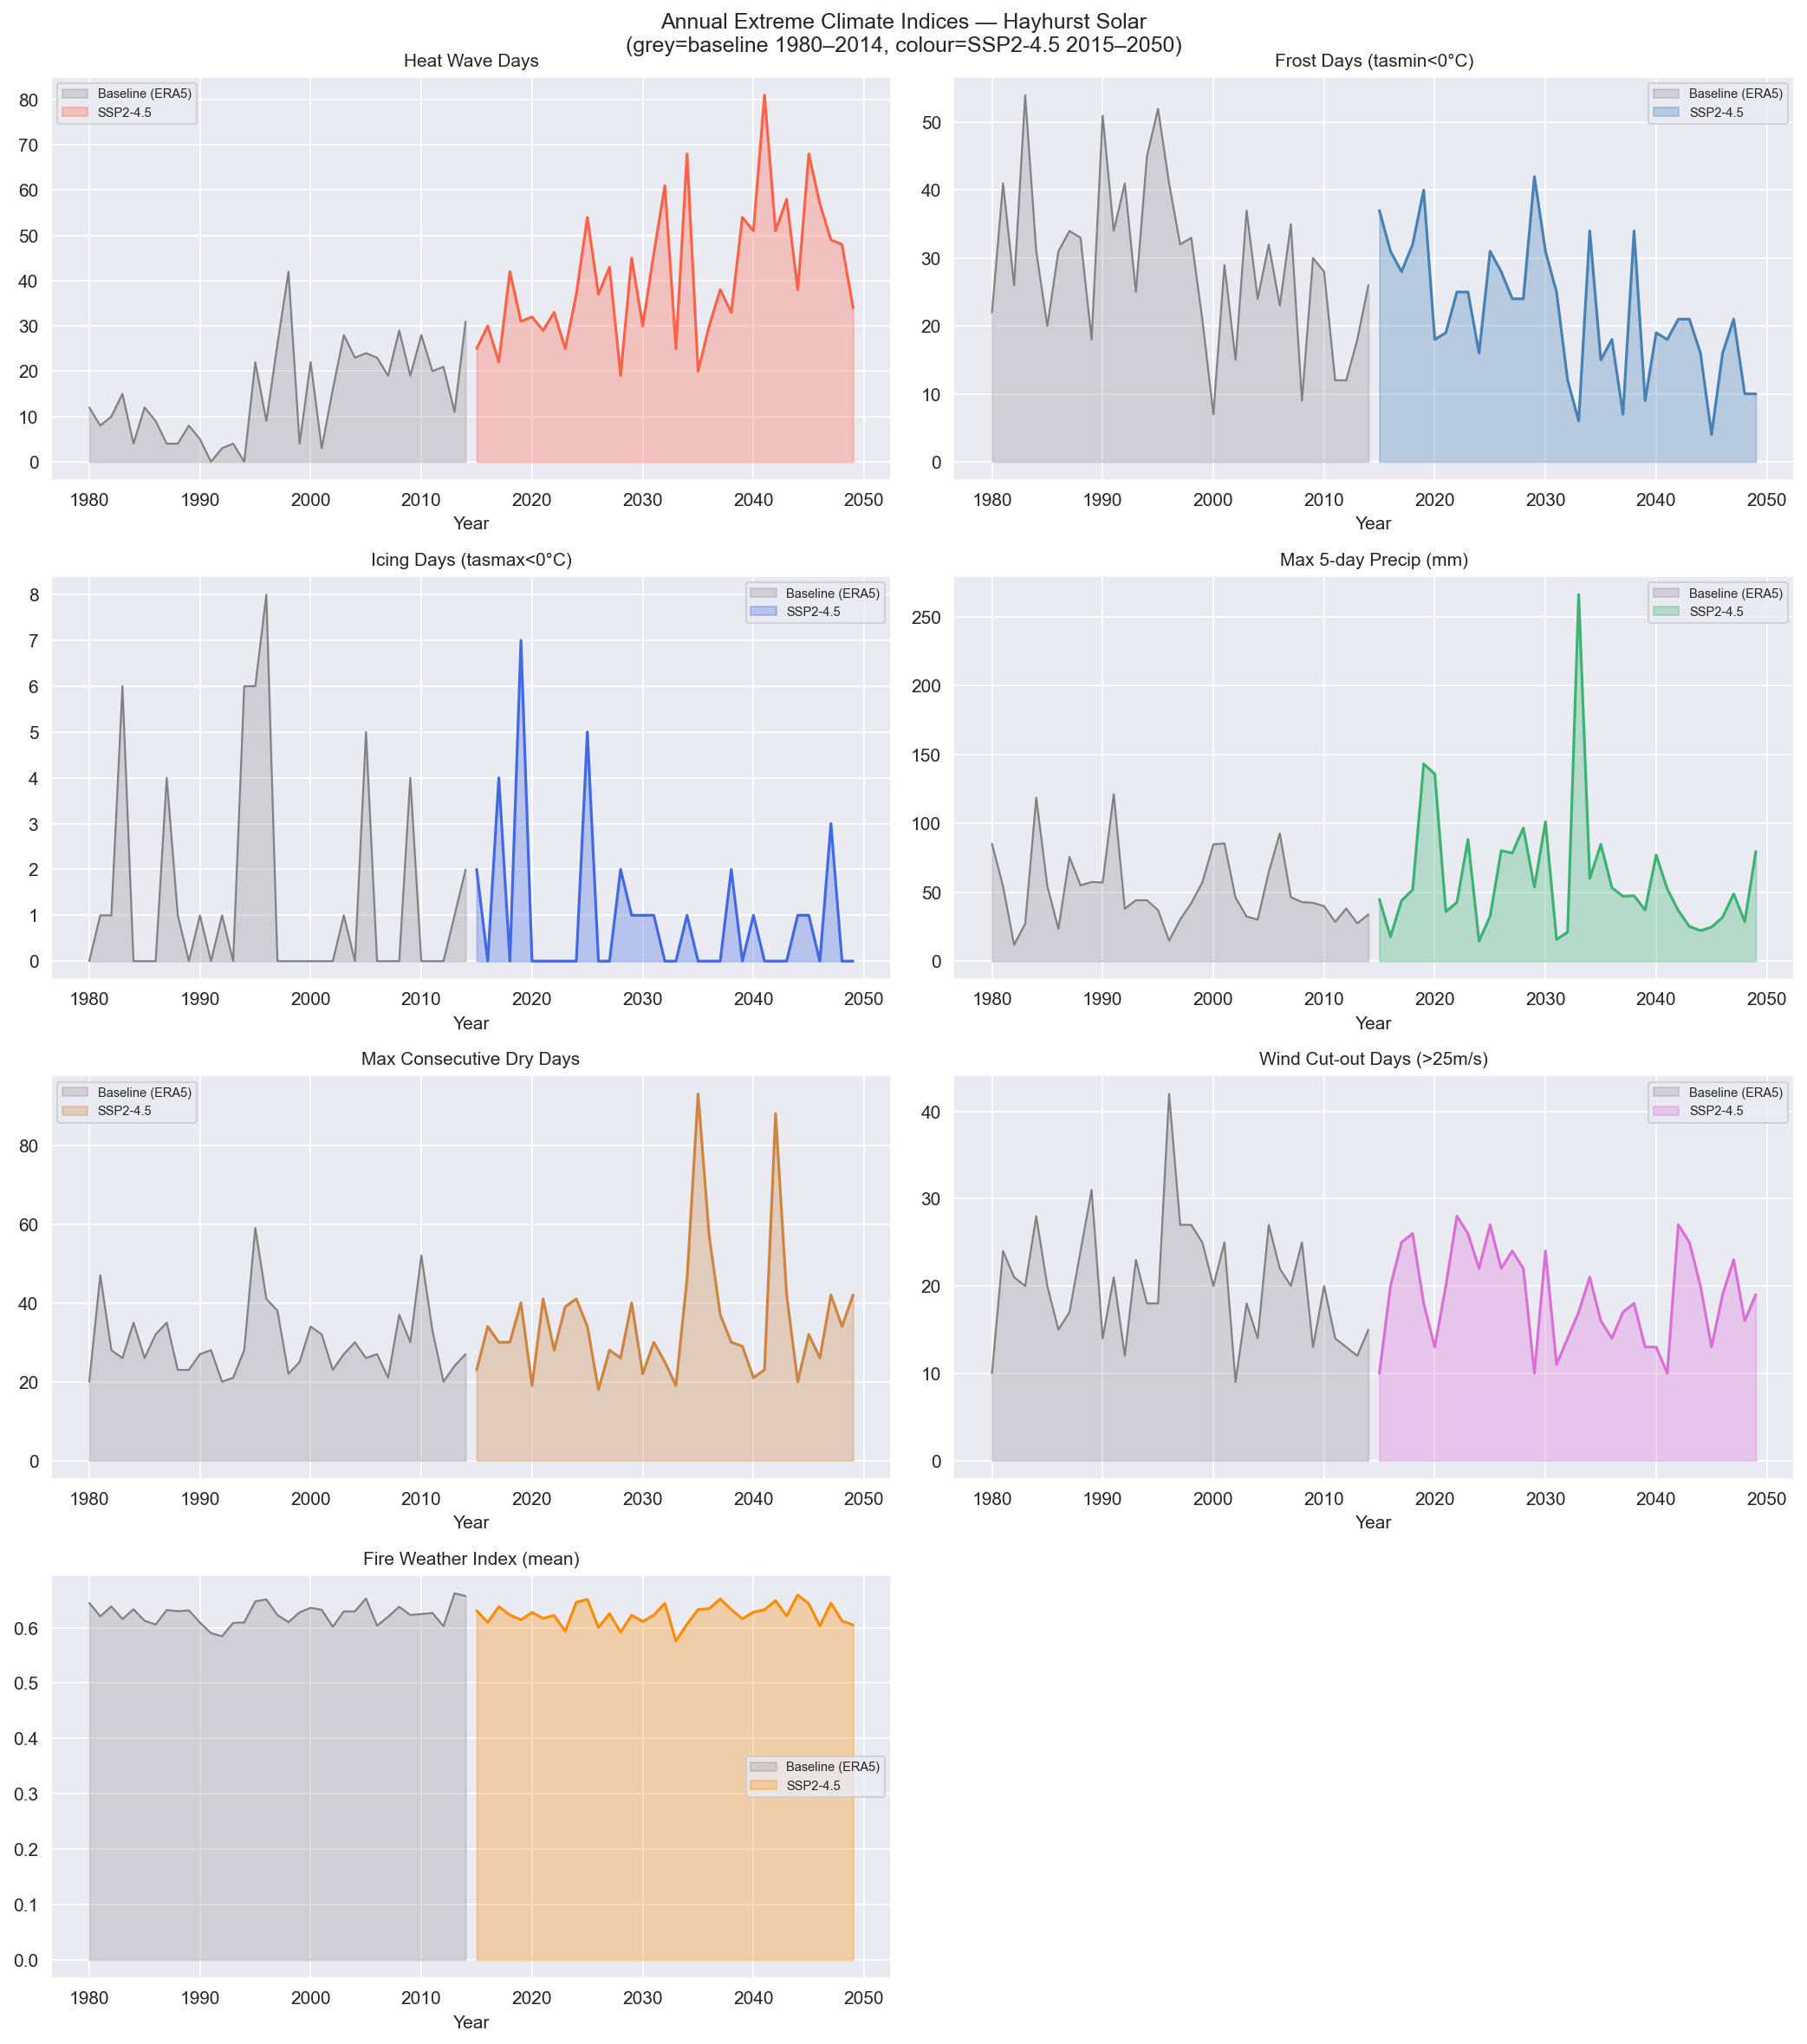

In [22]:
# ── Plot extreme indices over time ─────────────────────────────────────────────
INDEX_META = {
    'heat_wave_days' : ('Heat Wave Days', 'tomato'),
    'frost_days'     : ('Frost Days (tasmin<0°C)', 'steelblue'),
    'icing_days'     : ('Icing Days (tasmax<0°C)', 'royalblue'),
    'rx5day_mm'      : ('Max 5-day Precip (mm)', 'mediumseagreen'),
    'max_dry_days'   : ('Max Consecutive Dry Days', 'peru'),
    'wind_cutout_days':('Wind Cut-out Days (>25m/s)', 'orchid'),
    'fwi_mean'       : ('Fire Weather Index (mean)', 'darkorange'),
}

fig, axes = plt.subplots(4, 2, figsize=(14, 16), sharex=False)
fig.suptitle('Annual Extreme Climate Indices — Hayhurst Solar\n(grey=baseline 1980–2014, colour=SSP2-4.5 2015–2050)',
             fontsize=12)

ax_list = axes.flatten()
for i, (col, (title, color)) in enumerate(INDEX_META.items()):
    ax = ax_list[i]
    # Baseline (grey)
    ax.fill_between(idx_base['year'],
                    idx_base[col] * 0,
                    idx_base[col],
                    alpha=0.25, color='grey', label='Baseline (ERA5)')
    ax.plot(idx_base['year'], idx_base[col], '-', color='grey', lw=1)
    # Future
    ax.fill_between(idx_future['year'],
                    idx_future[col] * 0,
                    idx_future[col],
                    alpha=0.3, color=color, label='SSP2-4.5')
    ax.plot(idx_future['year'], idx_future[col], '-', color=color, lw=1.5)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=7)
    ax.set_xlabel('Year')

# Hide last empty panel
ax_list[-1].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'extreme_indices.png', dpi=150)
plt.show()

---
## Section 4 — SCVR Computation

### What is SCVR?

**SCVR (Severe Climate Variability Rating)** quantifies how much the *area under
the empirical exceedance curve* changes between the historical baseline and a future
climate period.

$$\text{SCVR}(V, Y) = \frac{\text{Area}_{\text{future}} - \text{Area}_{\text{baseline}}}{\text{Area}_{\text{baseline}}}$$

where the exceedance area is computed as:
$$\text{Area} = \int_0^1 F^{-1}(1-p)\, dp \approx \texttt{trapz}(\text{sorted\_values}_{\text{desc}},\; p \in [0,1])$$

### Why 20-year windows?

Climate projections are noisy on single-year timescales — a single cold winter
or wet summer can dominate a one-year SCVR and hide the actual long-term trend.
We use **20-year rolling windows centered on target years** (2030, 2035, 2040, 2045, 2050)
to extract the climate *trend* signal from the noise.

For target year 2030: we use data from 2020–2040.  
For target year 2050: we use data from 2040–2050 (clipped to available data).

### SCVR = 0 means no change; positive = more extremes; negative = fewer extremes

In [23]:
# ── SCVR core function ────────────────────────────────────────────────────────
# (Same implementation validated in scripts/tests/test_scvr_math.py)

def compute_scvr(baseline_values: np.ndarray, future_values: np.ndarray) -> dict:
    """
    Compute SCVR as fractional change in area under the empirical exceedance curve.
    SCVR = (area_future - area_baseline) / area_baseline
    """
    b = np.sort(baseline_values[~np.isnan(baseline_values)])[::-1].astype(float)
    f = np.sort(future_values[~np.isnan(future_values)])[::-1].astype(float)

    exc_b = np.linspace(0, 1, len(b))
    exc_f = np.linspace(0, 1, len(f))

    area_b = float(np.trapezoid(b, exc_b))
    area_f = float(np.trapezoid(f, exc_f))

    scvr = (area_f - area_b) / area_b if area_b != 0 else 0.0

    return {
        'scvr': scvr, 'area_baseline': area_b, 'area_future': area_f,
        'n_baseline_days': len(b), 'n_future_days': len(f),
    }


# ── Build combined dataset (baseline + future joined on date) ─────────────────
# We combine baseline (1980–2014) and future (2015–2050) into one frame
# so we can slice windows across the join boundary
df_all = pd.concat([df_base, df_future], ignore_index=True).sort_values('date').reset_index(drop=True)

print(f'Combined dataset: {df_all.shape[0]:,} rows  ({df_all["year"].min()}–{df_all["year"].max()})')

Combined dataset: 25,568 rows  (1980–2049)


In [24]:
# ── Compute SCVR for all variables and target years ───────────────────────────
SCVR_VARIABLES = ['tasmax', 'tasmin', 'tas', 'pr', 'sfcWind', 'hurs', 'rsds']
TARGET_YEARS   = [2030, 2035, 2040, 2045, 2050]
WINDOW_HALF    = 10  # ±10 years around each target year = 20-year window total

# ⚠️  WINDOW SIZE CAVEAT — the 2045 and 2050 windows are SHORTER than intended:
#
#   Target 2030 → window 2020–2040 = 20 years  ✅ full window
#   Target 2035 → window 2025–2045 = 20 years  ✅ full window
#   Target 2040 → window 2030–2049 = 20 years  ✅ full window
#   Target 2045 → window 2035–2049 = 15 years  ⚠️ clipped (data ends 2049)
#   Target 2050 → window 2040–2049 = 10 years  ⚠️ clipped (data ends 2049)
#
# The 2045/2050 SCVR values are directionally correct but statistically less robust.
# Treat them as indicative, not precise. The n_future_days column in the output
# Parquet records the actual window size used so downstream code can flag these.

BASELINE_YEARS_MASK = (df_all['year'] >= 1980) & (df_all['year'] <= 2014)

scvr_rows = []

for var in SCVR_VARIABLES:
    baseline_vals = df_all.loc[BASELINE_YEARS_MASK, var].values

    for cy in TARGET_YEARS:
        w_start = cy - WINDOW_HALF
        w_end   = min(cy + WINDOW_HALF, 2049)  # clip to last year with valid data
        future_mask = (df_all['year'] >= w_start) & (df_all['year'] <= w_end)
        future_vals = df_all.loc[future_mask, var].values

        result = compute_scvr(baseline_vals, future_vals)
        scvr_rows.append({
            'site_id'         : SITE_ID,
            'scenario'        : SCENARIO_CODE,
            'model'           : MODEL.replace('_', '-'),
            'center_year'     : cy,
            'variable'        : var,
            'scvr'            : result['scvr'],
            'area_baseline'   : result['area_baseline'],
            'area_future'     : result['area_future'],
            'window_start_year': w_start,
            'window_end_year' : w_end,
            'n_baseline_days' : result['n_baseline_days'],
            'n_future_days'   : result['n_future_days'],
        })

df_scvr = pd.DataFrame(scvr_rows)
scvr_path = SITE_PROC_DIR / f'{SCENARIO_CODE}_{MODEL}_scvr.parquet'
df_scvr.to_parquet(scvr_path, index=False, engine='pyarrow')

print(f'SCVR table saved → {scvr_path.name}  ({len(df_scvr)} rows)')
print()

# Pivot for display
scvr_pivot = df_scvr.pivot(index='variable', columns='center_year', values='scvr').round(3)
print('SCVR Table (rows=variable, cols=target year):')
print(scvr_pivot.to_string())

SCVR table saved → ssp245_EC_Earth3P_HR_scvr.parquet  (35 rows)

SCVR Table (rows=variable, cols=target year):
center_year   2030   2035   2040   2045   2050
variable                                      
hurs         0.001 -0.011 -0.032 -0.067 -0.079
pr           0.119  0.056  0.011 -0.089 -0.178
rsds         0.009  0.010  0.011  0.014  0.017
sfcWind      0.002  0.001 -0.000 -0.002  0.004
tas          0.059  0.079  0.101  0.117  0.125
tasmax       0.042  0.056  0.074  0.086  0.092
tasmin       0.092  0.119  0.148  0.167  0.178


---
## Section 5 — Visualisation

Four plots that together tell the complete SCVR story:

- **Plot A** — Exceedance curve shift: the visual explanation of *what* SCVR measures
- **Plot B** — SCVR over time: *how fast* each climate stressor is increasing
- **Plot C** — SCVR heatmap: *at a glance* which variables and periods matter most
- **Plot D** — Temperature trend: sanity check that the warming signal is physically plausible

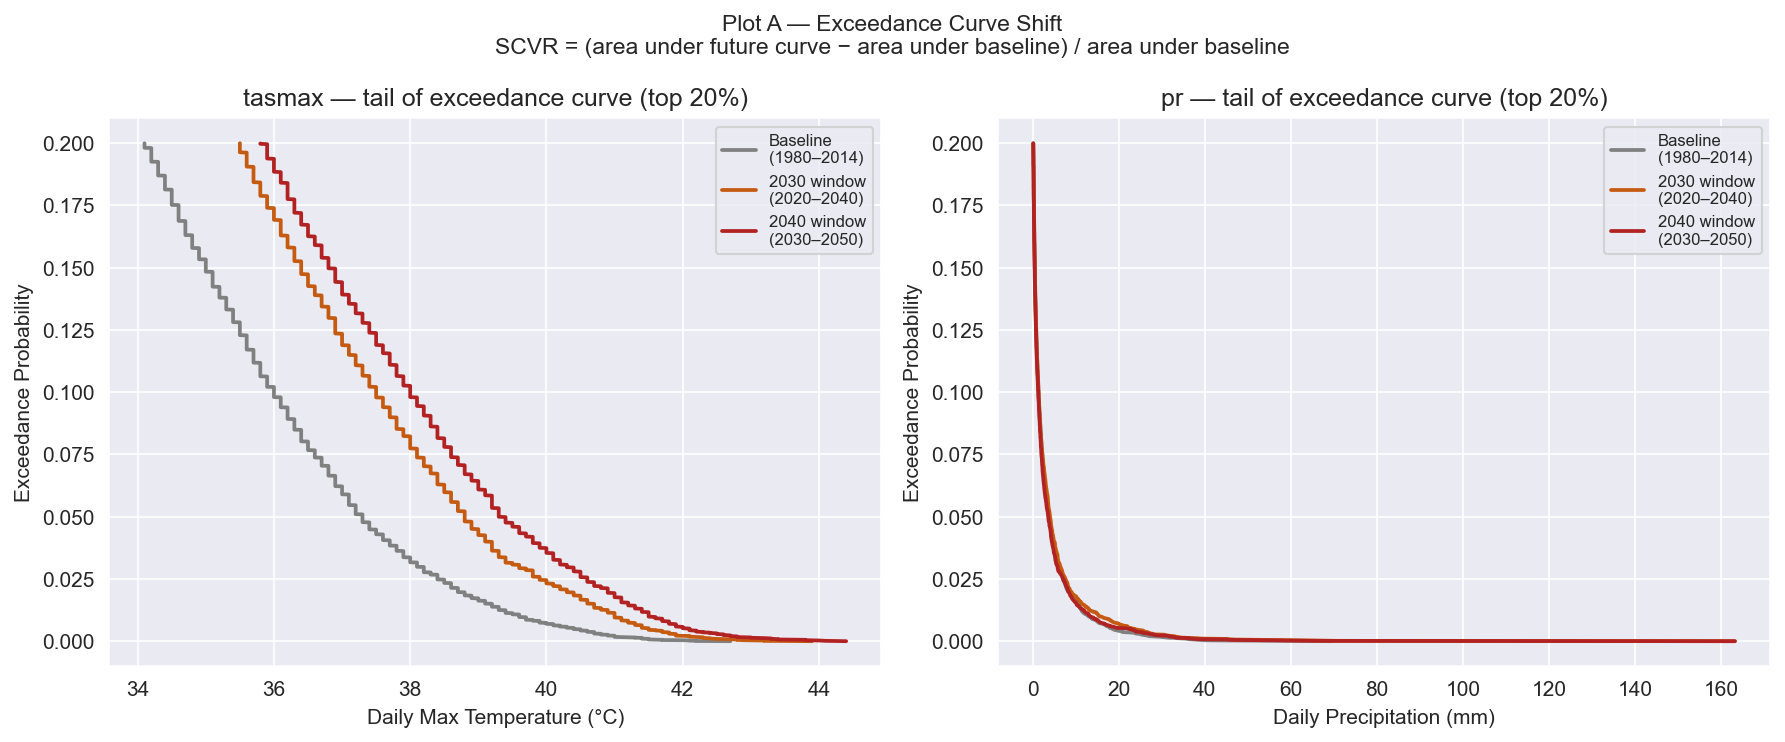

In [25]:
# ── Plot A — Exceedance Curve Shift ───────────────────────────────────────────
# Shows how the empirical exceedance curve shifts for tasmax and pr.
# The 'area between curves' is what SCVR measures.

def exceedance_curve(values: np.ndarray):
    """Returns (sorted_values_descending, exceedance_probs) for plotting."""
    v = np.sort(values[~np.isnan(values)])[::-1].astype(float)
    p = np.linspace(0, 1, len(v))
    return v, p


WINDOW_COLORS = {
    'Baseline\n(1980–2014)': ('grey', df_all[BASELINE_YEARS_MASK]),
    '2030 window\n(2020–2040)': (PALETTE['ssp245'], df_all[(df_all['year'] >= 2020) & (df_all['year'] <= 2040)]),
    '2040 window\n(2030–2050)': ('firebrick',        df_all[(df_all['year'] >= 2030) & (df_all['year'] <= 2050)]),
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Plot A — Exceedance Curve Shift\n'
             'SCVR = (area under future curve − area under baseline) / area under baseline',
             fontsize=11)

for ax, var, xlabel in zip(axes,
                            ['tasmax', 'pr'],
                            ['Daily Max Temperature (°C)', 'Daily Precipitation (mm)']):
    for label, (color, subset) in WINDOW_COLORS.items():
        vals = subset[var].values
        v, p = exceedance_curve(vals)
        # Show only the top 20% for clarity
        mask = p <= 0.20
        ax.plot(v[mask], p[mask], '-', color=color, lw=1.8, label=label)

    ax.set_xlabel(xlabel)
    ax.set_ylabel('Exceedance Probability')
    ax.legend(fontsize=8)
    ax.set_title(f'{var} — tail of exceedance curve (top 20%)')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'plot_A_exceedance_curves.png', dpi=150)
plt.show()

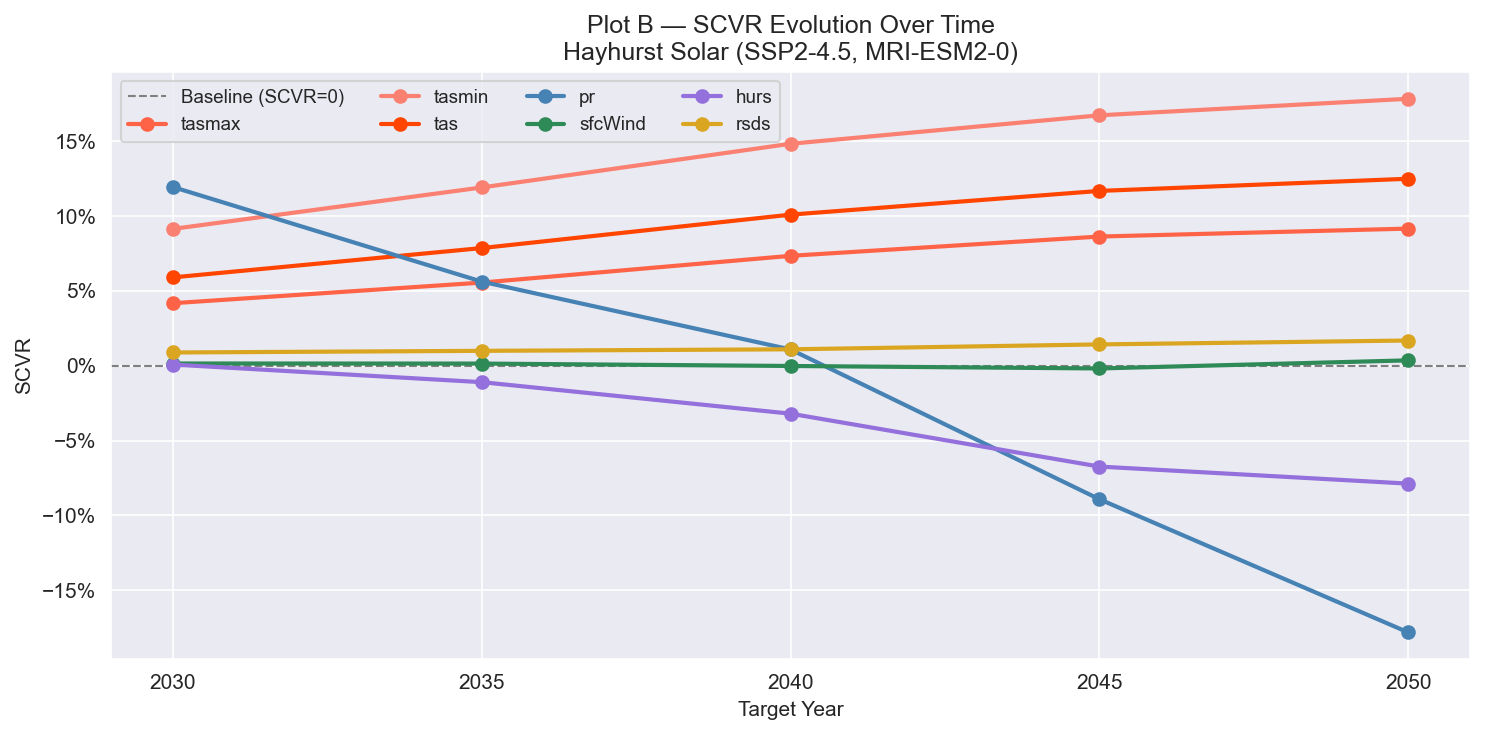

In [26]:
# ── Plot B — SCVR Over Time ────────────────────────────────────────────────────
# One line per variable; y=0 is "no change from baseline"

VAR_COLORS = {
    'tasmax': 'tomato', 'tasmin': 'salmon', 'tas': 'orangered',
    'pr': 'steelblue', 'sfcWind': 'seagreen',
    'hurs': 'mediumpurple', 'rsds': 'goldenrod',
}

fig, ax = plt.subplots(figsize=(10, 5))
ax.axhline(0, color='grey', lw=1, ls='--', label='Baseline (SCVR=0)')

for var in SCVR_VARIABLES:
    sub = df_scvr[df_scvr['variable'] == var].sort_values('center_year')
    ax.plot(sub['center_year'], sub['scvr'], 'o-',
            color=VAR_COLORS.get(var, 'black'), lw=2, ms=6, label=var)

ax.set_xlabel('Target Year')
ax.set_ylabel('SCVR')
ax.set_title('Plot B — SCVR Evolution Over Time\nHayhurst Solar (SSP2-4.5, MRI-ESM2-0)')
ax.set_xticks(TARGET_YEARS)
ax.legend(ncol=4, fontsize=9, loc='upper left')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'plot_B_scvr_over_time.png', dpi=150)
plt.show()

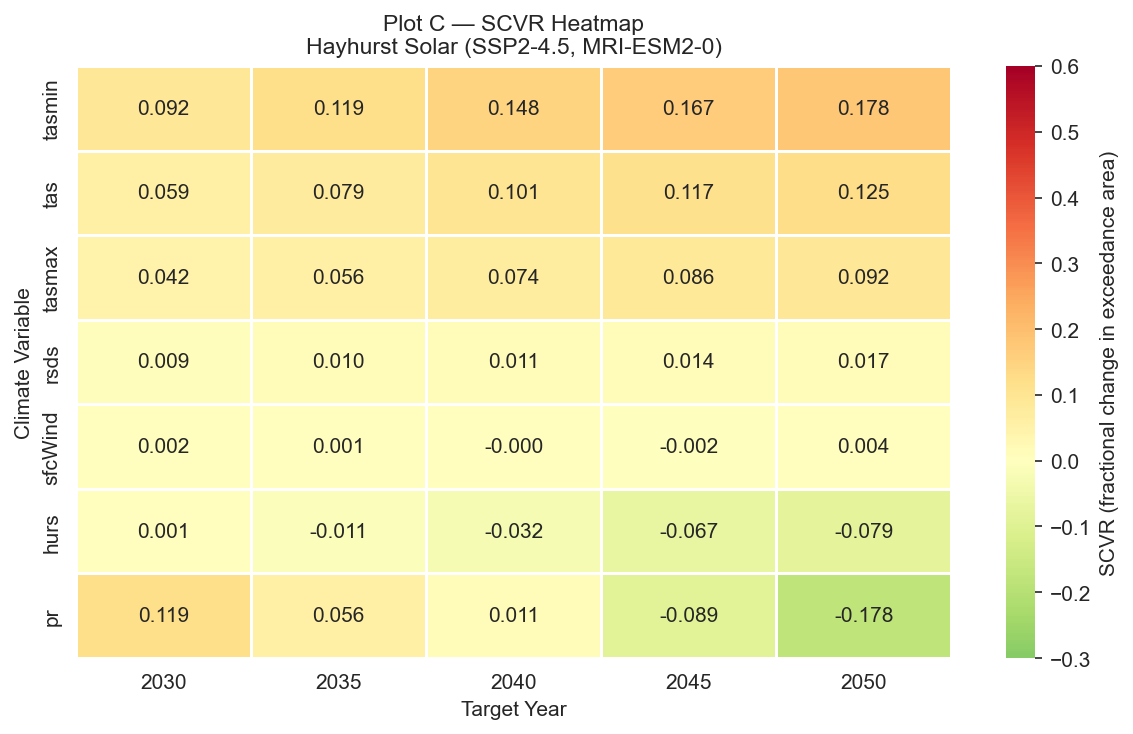

In [27]:
# ── Plot C — SCVR Heatmap ──────────────────────────────────────────────────────
# Variables × target years; colour = SCVR magnitude

fig, ax = plt.subplots(figsize=(8, 5))

pivot = df_scvr.pivot(index='variable', columns='center_year', values='scvr')
# Sort rows by 2050 SCVR descending for readability
pivot = pivot.sort_values(2050, ascending=False)

sns.heatmap(
    pivot,
    annot=True, fmt='.3f', cmap='RdYlGn_r',
    center=0, vmin=-0.3, vmax=0.6,
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'SCVR (fractional change in exceedance area)'}
)
ax.set_title('Plot C — SCVR Heatmap\nHayhurst Solar (SSP2-4.5, MRI-ESM2-0)',
             fontsize=11)
ax.set_xlabel('Target Year')
ax.set_ylabel('Climate Variable')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'plot_C_scvr_heatmap.png', dpi=150)
plt.show()

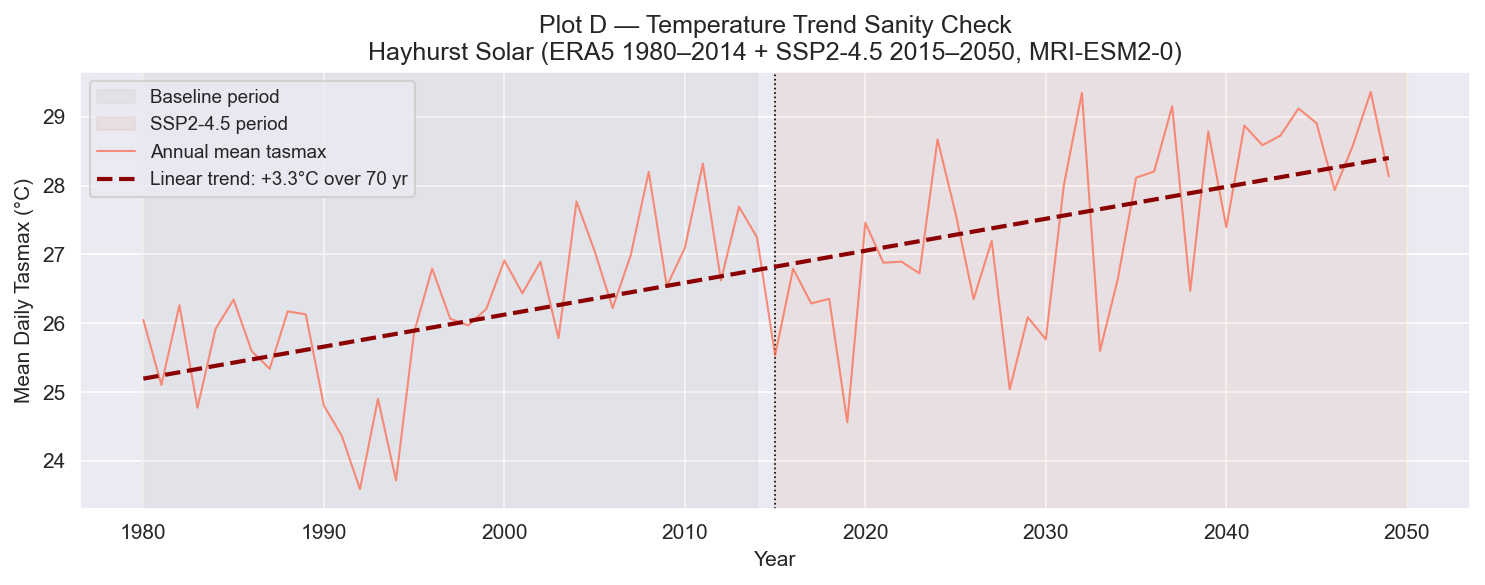

Linear warming rate: 0.46 °C/decade over 1980–2050
Total trend:        +3.3 °C over 70 years
Expected for SSP2-4.5 in West Texas: roughly +1.5 to +2.5°C — compare above.


In [28]:
# ── Plot D — Temperature Trend Sanity Check ────────────────────────────────────
# Annual mean tasmax 1980–2050; linear trend line overlaid.
# Expected: ~1.5–2°C warming over 70 years for SSP2-4.5 / West Texas.

annual_tasmax = df_all.groupby('year')['tasmax'].mean().reset_index()
annual_tasmax.columns = ['year', 'tasmax_mean']

# Linear trend
coef = np.polyfit(annual_tasmax['year'], annual_tasmax['tasmax_mean'], 1)
trend_line = np.polyval(coef, annual_tasmax['year'])
warming_70yr = coef[0] * 70

fig, ax = plt.subplots(figsize=(10, 4))

# Shade baseline / future periods
ax.axvspan(1980, 2014, alpha=0.07, color='grey', label='Baseline period')
ax.axvspan(2015, 2050, alpha=0.07, color=PALETTE['ssp245'], label='SSP2-4.5 period')
ax.axvline(2015, color='black', lw=0.8, ls=':')

ax.plot(annual_tasmax['year'], annual_tasmax['tasmax_mean'],
        '-', color='tomato', lw=1, alpha=0.7, label='Annual mean tasmax')
ax.plot(annual_tasmax['year'], trend_line,
        '--', color='darkred', lw=2,
        label=f'Linear trend: +{warming_70yr:.1f}°C over 70 yr')

ax.set_xlabel('Year')
ax.set_ylabel('Mean Daily Tasmax (°C)')
ax.set_title('Plot D — Temperature Trend Sanity Check\n'
             f'Hayhurst Solar (ERA5 1980–2014 + SSP2-4.5 2015–2050, MRI-ESM2-0)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'plot_D_temperature_trend.png', dpi=150)
plt.show()

print(f'Linear warming rate: {coef[0]*10:.2f} °C/decade over 1980–2050')
print(f'Total trend:        +{warming_70yr:.1f} °C over 70 years')
print('Expected for SSP2-4.5 in West Texas: roughly +1.5 to +2.5°C — compare above.')

---
## Section 6 — Summary

### SCVR Results Table

The table below shows how each climate variable's exceedance area changes
relative to the 1980–2014 baseline. Values are fractional (0.10 = +10% more extreme).

In [29]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary = df_scvr.pivot(index='variable', columns='center_year', values='scvr').round(3)
summary = summary.sort_values(2050, ascending=False)

# Add a readable description column from variables.json
summary.insert(0, 'description', [VARIABLES[v]['full_name'] if v in VARIABLES else v
                                   for v in summary.index])

print('=' * 80)
print('SCVR SUMMARY TABLE — Hayhurst Solar (SSP2-4.5, MRI-ESM2-0)')
print('Baseline: 1980–2014 ERA5 | Windows: ±10 years around each target year')
print('=' * 80)
print(summary.to_string())
print()
print('Interpretation:')
print('  Positive SCVR → more extremes (or more intense) than baseline')
print('  Negative SCVR → fewer extremes than baseline (e.g. fewer freeze days under warming)')
print('  SCVR = 0.10 → 10% increase in exceedance area')

SCVR SUMMARY TABLE — Hayhurst Solar (SSP2-4.5, MRI-ESM2-0)
Baseline: 1980–2014 ERA5 | Windows: ±10 years around each target year
center_year                                 description   2030   2035   2040   2045   2050
variable                                                                                  
tasmin       Daily Minimum Near-Surface Air Temperature  0.092  0.119  0.148  0.167  0.178
tas             Daily Mean Near-Surface Air Temperature  0.059  0.079  0.101  0.117  0.125
tasmax       Daily Maximum Near-Surface Air Temperature  0.042  0.056  0.074  0.086  0.092
rsds            Surface Downwelling Shortwave Radiation  0.009  0.010  0.011  0.014  0.017
sfcWind              Daily Mean Near-Surface Wind Speed  0.002  0.001 -0.000 -0.002  0.004
hurs          Daily Mean Near-Surface Relative Humidity  0.001 -0.011 -0.032 -0.067 -0.079
pr                              Daily Precipitation Sum  0.119  0.056  0.011 -0.089 -0.178

Interpretation:
  Positive SCVR → more extremes (or

In [30]:
# ── What's next ────────────────────────────────────────────────────────────────
print('=' * 80)
print('OUTPUT FILES')
print('=' * 80)
for p in sorted(SITE_RAW_DIR.glob('*.parquet')):
    size_kb = p.stat().st_size / 1024
    print(f'  raw/cmip6/{SITE_ID}/{p.name:<50} {size_kb:>7.0f} KB')
print()
for p in sorted(SITE_PROC_DIR.glob('*.parquet')):
    size_kb = p.stat().st_size / 1024
    print(f'  processed/scvr/{SITE_ID}/{p.name:<45} {size_kb:>7.0f} KB')
print()
for p in sorted(FIGURES_DIR.glob('*.png')):
    size_kb = p.stat().st_size / 1024
    print(f'  processed/scvr/{SITE_ID}/figures/{p.name:<40} {size_kb:>7.0f} KB')

print()
print('=' * 80)
print('NEXT STEPS (Notebook 02)')
print('=' * 80)
print('  1. Load the SCVR table above')
print('  2. Apply HCR coefficients (from literature review) per hazard type')
print('     → BI_climate(t) = BI_base × (1 + HCR(t))')
print('  3. Apply EFR models (Peck\'s, Coffin-Manson, Palmgren-Miner) per asset type')
print('     → IUL = EUL × [1 - Σ(EFR_i × SCVR_i)]')
print('  4. Repeat for Maverick Creek Wind (Concho TX, SSP2-4.5 + SSP5-8.5)')

OUTPUT FILES
  raw/cmip6/hayhurst_solar/historical_EC_Earth3P_HR_1980_2014.parquet             238 KB
  raw/cmip6/hayhurst_solar/ssp245_EC_Earth3P_HR_2015_2049.parquet                 238 KB

  processed/scvr/hayhurst_solar/ssp245_EC_Earth3P_HR_scvr.parquet                   8 KB

  processed/scvr/hayhurst_solar/figures/baseline_cdfs.png                             61 KB
  processed/scvr/hayhurst_solar/figures/baseline_seasonality.png                     211 KB
  processed/scvr/hayhurst_solar/figures/extreme_indices.png                          422 KB
  processed/scvr/hayhurst_solar/figures/plot_A_exceedance_curves.png                 117 KB
  processed/scvr/hayhurst_solar/figures/plot_B_scvr_over_time.png                     95 KB
  processed/scvr/hayhurst_solar/figures/plot_C_scvr_heatmap.png                       91 KB
  processed/scvr/hayhurst_solar/figures/plot_D_temperature_trend.png                 116 KB
  processed/scvr/hayhurst_solar/figures/sanity_monthly_tasmax.png         